In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('polynomial_regression_train.csv')
df.head(15)

,ID,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Target
0,1,-0.299150,0.980381,-1.244780,0.420551,-0.352235,8.168743e-10
1,2,-0.374319,-1.179867,0.615588,0.054701,0.687182,-5.081225e-10
2,3,-1.240429,-0.139086,-0.001653,0.487685,-0.242808,4.560170e-10
3,4,-0.429881,-1.724246,-0.098046,0.896504,0.318585,-2.647546e-09
4,5,-1.726345,1.945823,1.275979,-0.474670,1.050494,-1.704606e-08
5,6,0.719335,-0.958623,0.327252,-0.578998,-1.306745,-3.458655e-10
6,7,0.252856,-0.690294,0.737798,-1.752012,-1.811167,-7.451065e-09
7,8,0.324350,-0.514596,-1.864251,-0.019060,-0.026929,3.512555e-09
8,9,-0.632990,-0.959605,-1.719171,1.408667,-1.114809,-1.301514e-09
9,10,-1.078015,0.524848,0.079212,-1.729532,-1.358179,-9.762635e-09


In [4]:
X=df.iloc[:,1:-1].to_numpy()
print(X)

[[-2.99150217e-01  9.80381374e-01 -1.24478036e+00  4.20551444e-01
  -3.52234517e-01]
 [-3.74319425e-01 -1.17986704e+00  6.15588148e-01  5.47011163e-02
   6.87182229e-01]
 [-1.24042933e+00 -1.39085810e-01 -1.65302067e-03  4.87685105e-01
  -2.42808052e-01]
 ...
 [-1.67753838e+00  1.75827436e+00  1.02053447e+00  3.46495673e-01
   1.31375468e+00]
 [ 1.31334466e+00  3.15358042e-01 -6.06291322e-02  7.03251230e-01
  -6.18519654e-01]
 [-9.99869575e-01 -1.65745830e+00 -8.12632269e-01  1.01871706e+00
  -1.23699276e+00]]


In [5]:
X_train=X[:28800,:].copy()
print(X_train)


[[-2.99150217e-01  9.80381374e-01 -1.24478036e+00  4.20551444e-01
  -3.52234517e-01]
 [-3.74319425e-01 -1.17986704e+00  6.15588148e-01  5.47011163e-02
   6.87182229e-01]
 [-1.24042933e+00 -1.39085810e-01 -1.65302067e-03  4.87685105e-01
  -2.42808052e-01]
 ...
 [-5.98548912e-01 -1.76935809e+00  9.29546049e-01  1.08880320e+00
  -9.02386222e-01]
 [-1.03249330e+00  1.72513744e+00 -7.25270703e-01  1.81278209e+00
  -1.24033352e+00]
 [ 1.75169553e+00 -1.54833652e+00 -4.45047145e-02 -1.45993145e+00
   1.03567079e+00]]


In [6]:
y=df.iloc[:,-1].to_numpy()
print(y)


[ 8.16874285e-10 -5.08122456e-10  4.56017046e-10 ... -1.09620443e-08
  1.96209742e-09  5.00055158e-10]


In [7]:
y_train=y[:28800].copy()
print(y_train)


[ 8.16874285e-10 -5.08122456e-10  4.56017046e-10 ...  6.97383054e-09
  2.06139760e-09  2.04279337e-08]


In [8]:
X_train_norm=X_train.copy()
mu=np.mean(X_train_norm,axis=0)
sigma=np.std(X_train_norm,axis=0)
X_train_norm=(X_train_norm-mu)/sigma
print(X_train_norm)

[[-0.27073224  0.847466   -1.08274859  0.36328388 -0.29630531]
 [-0.33557927 -1.02571555  0.5310429   0.04603189  0.60774294]
 [-1.08275563 -0.12323962 -0.00438787  0.42149973 -0.20113001]
 ...
 [-0.52901773 -1.53687147  0.80338819  0.94276732 -0.77480799]
 [-0.90337321  1.49325438 -0.6320958   1.57057528 -1.0687427 ]
 [ 1.49849295 -1.34522058 -0.04155992 -1.26740197  0.91084608]]


In [9]:
X_train_norm_int=X_train_norm.copy()
for i in range(5):
    for j in range(i,5):
        X_train_norm_int=np.hstack((X_train_norm_int,(X_train_norm_int[:,i]*X_train_norm_int[:,j]).reshape(-1,1)))

        
for i in range(5):
    for j in range(i,5):
        for k in range(j,5):
            X_train_norm_int=np.hstack((X_train_norm_int,(X_train_norm_int[:,i]*X_train_norm_int[:,j]*X_train_norm_int[:,k]).reshape(-1,1)))

            


In [10]:
X_cv=X[28800:38400,:].copy()
print(X_cv)


[[-1.12977824  0.29124463 -1.22665725 -1.15948082 -0.8108665 ]
 [ 1.97599093  0.17416095 -0.10547698  1.81846949 -1.37655853]
 [-0.41640846  1.92518964 -1.99868067 -0.3155137   0.90563084]
 ...
 [ 0.97695046  0.87605478 -0.2241141  -0.49749    -0.42922919]
 [-0.0366634  -1.15333804  1.76457421  0.16863106  0.23840294]
 [-1.14530852 -0.74098262 -1.18714301  0.50568926  1.19654138]]


In [11]:
X_cv_norm=X_cv.copy()
X_cv_norm=(X_cv_norm-mu)/sigma
X_cv_norm_int=X_cv_norm.copy()

for i in range(5):
    for j in range(i,5):
        X_cv_norm_int=np.hstack((X_cv_norm_int,(X_cv_norm_int[:,i]*X_cv_norm_int[:,j]).reshape(-1,1)))

        
for i in range(5):
    for j in range(i,5):
        for k in range(j,5):
            X_cv_norm_int=np.hstack((X_cv_norm_int,(X_cv_norm_int[:,i]*X_cv_norm_int[:,j]*X_cv_norm_int[:,k]).reshape(-1,1)))

            


In [12]:
J_hist=[]
w=np.zeros(55)
b=np.mean(y_train)
for i in range(1000):
    if i%100==0:
        errors=np.dot(X_train_norm_int,w)+b-y_train
        J_hist.append(np.dot(errors.T,errors)/(2*28800)+0.04*np.dot(w,w)/(2*28800))
        print(J_hist[-1])
    dj_dw=np.dot(X_train_norm_int.T,np.dot(X_train_norm_int,w)+b-y_train)/28800+0.04*w/28800
    dj_db=np.dot(np.ones_like(X_train_norm_int[:,0]),(np.dot(X_train_norm_int,w)+b-y_train))/28800
    w-=0.1*dj_dw
    b-=0.1*dj_db

    


5.730584421447067e-17
2.2649099344544774e-17
2.2609718750828317e-17
2.2601779710257195e-17
2.2600176731608065e-17
2.2599852777988508e-17
2.2599787266847375e-17
2.2599774012132384e-17
2.2599771329121902e-17
2.2599770785799747e-17


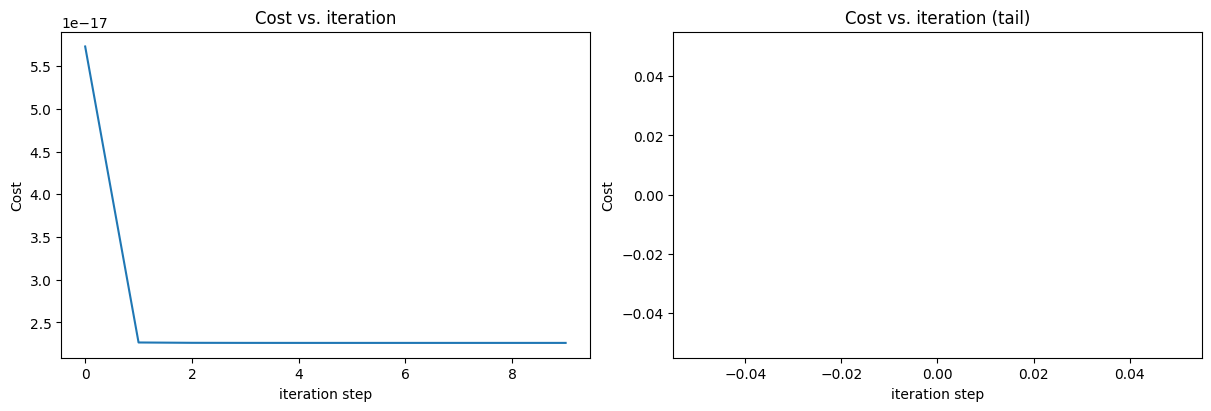

In [13]:
fig,(ax1,ax2)=plt.subplots(1,2,constrained_layout=True,figsize=(12, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])),J_hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step') 
plt.show()

In [14]:
df=pd.read_csv('polynomial_regression_test.csv')
print(df)

          ID  Feature_1  Feature_2  Feature_3  Feature_4  Feature_5
0          1   1.718004  -0.201814   0.791965  -0.410485   1.678171
1          2   0.782395   0.897345  -0.059263  -1.725306  -1.363520
2          3   0.619033   0.397670  -0.506356  -0.546682  -1.629186
3          4   1.950046  -1.874789  -0.144491   1.952435   1.908823
4          5   0.097417   0.960511  -1.031956  -1.585839  -1.297509
...      ...        ...        ...        ...        ...        ...
11995  11996   1.264677  -0.975995  -1.522923  -0.894496   1.166645
11996  11997  -1.134109   1.309373   1.057666  -1.103589   0.368445
11997  11998  -1.557074  -1.065746   1.440004   0.392618  -0.867881
11998  11999  -0.750905   0.354496  -0.893223   0.960500  -1.309842
11999  12000   0.052107   0.073239  -0.593130   0.258087   1.730319

[12000 rows x 6 columns]


In [15]:
X_test=df.iloc[:,1:].to_numpy()
print(X_test)

[[ 1.71800361 -0.20181414  0.79196547 -0.410485    1.67817084]
 [ 0.78239488  0.89734536 -0.05926334 -1.7253058  -1.36351971]
 [ 0.61903308  0.39766993 -0.50635589 -0.5466817  -1.62918559]
 ...
 [-1.55707406 -1.06574636  1.4400041   0.39261787 -0.86788111]
 [-0.75090545  0.35449601 -0.89322336  0.96050028 -1.30984159]
 [ 0.05210718  0.07323875 -0.59313035  0.25808702  1.73031892]]


In [16]:
y_test=df.iloc[:,-1].to_numpy()
print(y_test)

[ 1.67817084 -1.36351971 -1.62918559 ... -0.86788111 -1.30984159
  1.73031892]


In [17]:
X_test_norm=X_test.copy()
X_test_norm=(X_test_norm-mu)/sigma
print(X_test_norm)

[[ 1.46942758 -0.17763223  0.68404281 -0.35736047  1.46967011]
 [ 0.66229592  0.77546432 -0.05436241 -1.49752488 -1.17588573]
 [ 0.52136684  0.34218878 -0.4421964  -0.47546525 -1.4069526 ]
 ...
 [-1.35591895 -0.92675992  1.24618909  0.33906091 -0.74479665]
 [-0.66045279  0.30475207 -0.77778767  0.83150773 -1.12919839]
 [ 0.03229077  0.06086997 -0.5174696   0.22240069  1.51502668]]


In [18]:
X_test_norm_int=X_test_norm.copy()
for i in range(5):
    for j in range(i,5):
        X_test_norm_int=np.hstack((X_test_norm_int,(X_test_norm_int[:,i]*X_test_norm_int[:,j]).reshape(-1,1)))

        
for i in range(5):
    for j in range(i,5):
        for k in range(j,5):
            X_test_norm_int=np.hstack((X_test_norm_int,(X_test_norm_int[:,i]*X_test_norm_int[:,j]*X_test_norm_int[:,k]).reshape(-1,1)))

            


In [19]:
print(np.dot(X_test_norm_int,w)+b)

[ 1.71424330e-08 -8.81409913e-09 -4.69734390e-09 ...  1.39148889e-09
  3.37734525e-09 -6.94458937e-09]


In [20]:
df=pd.read_csv('polynomial_regression_train.csv')
X=df.iloc[:,1:-1].to_numpy()
y=df.iloc[:,-1].to_numpy()
X_norm=X.copy()
mu=np.mean(X_norm,axis=0)
sigma=np.std(X_norm,axis=0)
X_norm=(X_norm-mu)/sigma

X_norm_int=X_norm.copy()
for i in range(5):
    for j in range(i,5):
        X_norm_int=np.hstack((X_norm_int,(X_norm_int[:,i]*X_norm_int[:,j]).reshape(-1,1)))

        
for i in range(5):
    for j in range(i,5):
        for k in range(j,5):
            X_norm_int=np.hstack((X_norm_int,(X_norm_int[:,i]*X_norm_int[:,j]*X_norm_int[:,k]).reshape(-1,1)))


In [21]:
print(y)

[ 8.16874285e-10 -5.08122456e-10  4.56017046e-10 ... -1.09620443e-08
  1.96209742e-09  5.00055158e-10]


In [25]:
y_pred=np.dot(X_norm_int,w)+b
print(y_pred)

[ 4.28660876e-09 -3.38360276e-09  5.46163217e-09 ...  5.22758087e-09
  2.33412071e-09  2.02628952e-09]


In [26]:
print(np.mean(y))

-3.269558128553122e-10


In [28]:
r2=1-np.dot(y-y_pred,y-y_pred)/np.dot(y-np.mean(y),y-np.mean(y))
print(r2)

0.6022268146612373
